# Volve 3 — wells, nodal analysis, SURF network, and flow assurance

**Notebook 3 of 5 — integrated Volve field evaluation**

The authoritative input boundary is Equinor's Volve Data Village
listing in Databricks Marketplace. The notebook can read an
installed Unity Catalog volume directly or securely download only
selected files into Colab. It never stores credentials or
redistributes the complete Volve package.

A deterministic teaching fixture is used during unauthenticated
clean-runtime validation. Every such result is marked
**DEMONSTRATION_FALLBACK** and must not be described as measured
Volve data, a history match, a reserves statement, or certified
design.


## Learning outcomes and engineering decisions

            - select well trajectories, completions, and production history from Marketplace
- derive productivity and injectivity evidence instead of assuming one index
- construct IPR and VLP curves and locate stable operating points
- screen tubing, choke, manifold, flowline, riser, and export pressure losses
- evaluate temperature, hydrate margin, erosion, slugging, and cooldown
- deliver well and network envelopes to the facilities model

            The discipline result is written as a versioned handoff contract.
            Downstream notebooks consume quantities with names, units, source
            mode, assumptions, uncertainty, and validity limits rather than
            relying on hidden notebook state.


## End-to-end architecture

The series follows one controlled chain:

**Marketplace assets → seismic and logs → static model → PVT and
reservoir forecast → well and SURF deliverability → facilities and
export constraints → field scenarios and decisions**

Specialist tools retain their roles. segyio handles SEG-Y, lasio
and dlisio handle logs, OPM Flow or its deck interface handles
dynamic reservoir simulation, resdata inspects OPM results, and
NeqSim owns fluid characterization, PVT, flow assurance, process
simulation, equipment duties, and composable surface streams.


## Data provenance, licence, and claim boundary

Primary sources:

- [Databricks Marketplace: Equinor Volve Data Village](https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22/Equinor-ASA_Volve-Data-Village)
- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Volve data licence](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [Databricks Marketplace access guidance](https://docs.databricks.com/aws/en/marketplace/get-started-consumer)
- [Databricks Files API for Unity Catalog volumes](https://docs.databricks.com/aws/en/volumes/volume-files)

The raw package remains in the user's read-only Marketplace share.
Generated working tables contain only selected or derived values
and retain the source path and digest when real files are used.


## Clean-runtime setup and NeqSim source policy

Normal Colab execution clones current equinor/neqsim master,
records the resolved commit, builds the runtime JAR, adds it to the
JVM before importing NeqSim, and verifies the loaded class origin.
The Python package remains the JPype bridge. Local validation can
set VOLVE_VALIDATION_MODE=1 to use the pinned 3.17.0 release JAR;
that mode validates notebook logic but does not replace the
required current-master and Databricks acceptance run.


In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import hashlib
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys


VALIDATION_MODE = os.environ.get("VOLVE_VALIDATION_MODE") == "1"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
NEQSIM_REPOSITORY_URL = "https://github.com/equinor/neqsim"

if not VALIDATION_MODE:
    required = {
        "neqsim": "3.17.0",
        "databricks-sdk": "0.72.0",
        "segyio": "1.9.14",
        "lasio": "0.32",
        "dlisio": "1.0.3",
    }
    specifications = [
        f"{package}=={required_version}"
        for package, required_version in required.items()
    ]
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *specifications],
        check=True,
        timeout=900,
    )
    source_dir = Path("/content/neqsim-master")
    if not source_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_REPOSITORY_URL,
                str(source_dir),
            ],
            check=True,
            timeout=300,
        )
    resolved_commit = subprocess.run(
        ["git", "-C", str(source_dir), "rev-parse", "HEAD"],
        capture_output=True,
        check=True,
        text=True,
        timeout=60,
    ).stdout.strip()
    subprocess.run(
        [str(source_dir / "mvnw"), "-q", "-DskipTests", "package"],
        check=True,
        cwd=source_dir,
        timeout=1800,
    )
    runtime_jars = sorted((source_dir / "target").glob("neqsim-*-jar-with-dependencies.jar"))
    if not runtime_jars:
        raise RuntimeError("Current-master NeqSim runtime JAR was not built.")
    os.environ["NEQSIM_JVM_AUTOSTART"] = "false"
    import jpype

    jpype.addClassPath(str(runtime_jars[-1]))
    jpype.startJVM(convertStrings=False)
else:
    resolved_commit = "release-3.17.0-validation-runtime"

from neqsim import jneqsim
from neqsim.thermo import TPflash

protection = (
    jneqsim.thermo.system.SystemSrkEos.class_
    .getProtectionDomain()
    .getCodeSource()
)
runtime_origin = str(protection.getLocation()) if protection else "bundled JAR"
print(
    {
        "Python": platform.python_version(),
        "NeqSim bridge": version("neqsim"),
        "source ref": NEQSIM_SOURCE_REF,
        "resolved commit": resolved_commit,
        "runtime origin": runtime_origin,
        "validation mode": VALIDATION_MODE,
    }
)


{'Python': '3.12.13', 'NeqSim bridge': '3.17.0', 'source ref': 'master', 'resolved commit': 'release-3.17.0-validation-runtime', 'runtime origin': 'None', 'validation mode': True}


In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

series_dir = Path.cwd()
if not (series_dir / "volve_common.py").is_file():
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=300,
        )
    series_dir = (
        repository_dir
        / "notebooks"
        / "fielddevelopment"
        / "volve"
    )
sys.path.insert(0, str(series_dir))

import volve_common as vc

work_dir = Path(
    os.environ.get("VOLVE_WORK_DIR", str(series_dir / "work"))
)
work_dir.mkdir(parents=True, exist_ok=True)
source = vc.resolve_source()
display(vc.source_table(source))


,item,value
0,resolved mode,demonstration-fallback
1,Marketplace listing,https://marketplace.databricks.com/details/5c3...
2,volume root,not mounted
3,credentials,none
4,measured Volve data loaded,False
5,claim boundary,Deterministic teaching fixtures are used. Resu...


## Marketplace ingestion and bounded file selection

The listing contains tables and non-tabular files. Large SEG-Y,
DLIS, Eclipse restart, and report assets are normally shared as
Unity Catalog volume files. Colab therefore uses the Databricks
Files API and downloads only paths selected for the calculation.
The complete 5 TB-scale package is never copied.

Set VOLVE_DATA_MODE=marketplace and either:

1. point VOLVE_VOLUME_ROOT to an existing mounted or exported
   Marketplace directory; or
2. set VOLVE_REMOTE_VOLUME_ROOT to the Unity Catalog volume path and
   store DATABRICKS_HOST and DATABRICKS_TOKEN as Colab secrets.


In [3]:
if source.mode == "marketplace-local-volume":
    inventory = vc.inventory_local_volume(Path(source.volume_root))
elif source.mode == "marketplace-remote-volume":
    inventory = vc.list_remote_directory(source.volume_root)
else:
    inventory = vc.demonstration_inventory()

domain_summary = (
    inventory.groupby("domain", as_index=False)
    .agg(file_count=("relative_path", "size"), bytes=("bytes", "sum"))
    .sort_values("bytes", ascending=False)
)
domain_summary["size_GB"] = domain_summary["bytes"] / 1.0e9
display(domain_summary[["domain", "file_count", "size_GB"]])
display(inventory.head(12))


,domain,file_count,size_GB
4,seismic,1,3.20000
3,reservoir-model,3,2.91180
6,well-log,2,0.32420
5,static-model,1,0.00850
0,facilities-document,1,0.00530
1,production-history,1,0.00240
7,well-trajectory,1,0.00064
2,pvt,1,0.00012


,relative_path,suffix,bytes,domain
0,Seismic/ST0202/stacked_volume.sgy,.sgy,3200000000,seismic
1,Well_logs/15_9-F-1_C/composite.las,.las,4200000,well-log
2,Well_logs/15_9-F-14/formation_eval.dlis,.dlis,320000000,well-log
3,Reservoir_model/VOLVE.DATA,.data,1800000,reservoir-model
4,Reservoir_model/VOLVE.EGRID,.egrid,210000000,reservoir-model
5,Reservoir_model/VOLVE.UNRST,.unrst,2700000000,reservoir-model
6,Production/volve_daily_production.xlsx,.xlsx,2400000,production-history
7,Wells/well_trajectories.csv,.csv,640000,well-trajectory
8,PVT/representative_fluid_composition.xlsx,.xlsx,120000,pvt
9,Static_model/top_hugin_surface.txt,.txt,8500000,static-model


## 1. Reservoir handoff, trajectories, and completion context

A measured-data run joins deviation surveys, casing and tubing
design, perforations, completion strings, well tests, pressure
surveys, and allocation data. The join key must be a normalized
wellbore identifier; a platform slot, parent well, and sidetrack are
not interchangeable.


In [4]:
reservoir_contract_path = work_dir / "02_pvt_reservoir_forecast.json"
if reservoir_contract_path.is_file():
    reservoir_contract = vc.read_contract(reservoir_contract_path)
    bubble_pressure_bara = float(
        reservoir_contract["bubble_pressure_bara"]
    )
else:
    bubble_pressure_bara = 180.0

if source.measured_data_loaded:
    trajectory_path = vc.select_asset(
        inventory,
        "well-trajectory",
        environment_name="VOLVE_TRAJECTORY_PATH",
    )
    print({"selected trajectory": trajectory_path})
    raise RuntimeError(
        "Marketplace trajectory parsing is required for a measured-data run."
    )
trajectories = vc.demo_well_trajectories()
production = vc.demo_production_history()
print(
    {
        "trajectory rows": len(trajectories),
        "wells": trajectories["well"].nunique(),
        "data status": trajectories["data_status"].unique().tolist(),
    }
)


{'trajectory rows': 400, 'wells': 5, 'data status': ['DEMONSTRATION_FALLBACK']}


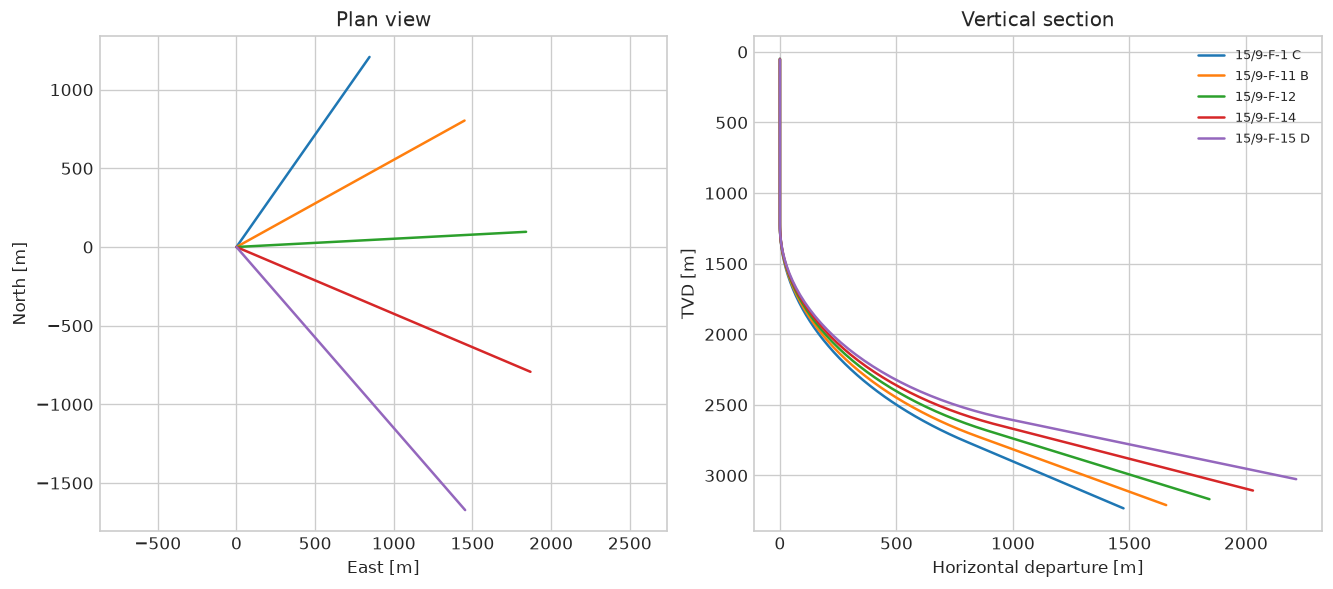

In [5]:
trajectory_figure, trajectory_axes = plt.subplots(
    1,
    2,
    figsize=(11.0, 4.8),
    constrained_layout=True,
)
for well_name, well_data in trajectories.groupby("well"):
    trajectory_axes[0].plot(
        well_data["east_m"],
        well_data["north_m"],
        label=well_name,
    )
    horizontal_departure = np.sqrt(
        well_data["east_m"] ** 2 + well_data["north_m"] ** 2
    )
    trajectory_axes[1].plot(
        horizontal_departure,
        well_data["tvd_m"],
        label=well_name,
    )
trajectory_axes[0].set(
    xlabel="East [m]",
    ylabel="North [m]",
    title="Plan view",
)
trajectory_axes[0].axis("equal")
trajectory_axes[1].invert_yaxis()
trajectory_axes[1].set(
    xlabel="Horizontal departure [m]",
    ylabel="TVD [m]",
    title="Vertical section",
)
trajectory_axes[1].legend(fontsize=8)
plt.show()


## 2. Productivity and injectivity evidence

For a single-phase radial check,

$$q=\frac{2\pi kh\Delta p}{\mu B\left[\ln(r_e/r_w)-0.75+s\right]}$$

The effective $kh$, skin $s$, mobility, and boundary behavior should
come from tests, logs, SCAL, and reservoir simulation. The
demonstration assigns well-specific indices only to illustrate
nodal analysis and declining pressure.


In [6]:
well_names = sorted(production["well"].unique())
productivity = pd.DataFrame(
    {
        "well": well_names,
        "reservoir_pressure_bara": [230.0, 225.0, 220.0, 215.0, 210.0],
        "bubble_pressure_bara": bubble_pressure_bara,
        "productivity_index_Sm3_day_bar": [42.0, 38.0, 35.0, 31.0, 28.0],
        "skin": [1.0, 2.5, 0.5, 3.0, 1.8],
        "completion_length_m": [450.0, 520.0, 480.0, 610.0, 560.0],
    }
)
productivity["kh_proxy_mD_m"] = (
    productivity["productivity_index_Sm3_day_bar"]
    * (productivity["skin"] + 6.5)
    * 18.0
)
display(productivity)


,well,reservoir_pressure_bara,bubble_pressure_bara,productivity_index_Sm3_day_bar,skin,completion_length_m,kh_proxy_mD_m
0,15/9-F-1 C,230.0,178.840271,42.0,1.0,450.0,5670.0
1,15/9-F-11 B,225.0,178.840271,38.0,2.5,520.0,6156.0
2,15/9-F-12,220.0,178.840271,35.0,0.5,480.0,4410.0
3,15/9-F-14,215.0,178.840271,31.0,3.0,610.0,5301.0
4,15/9-F-15 D,210.0,178.840271,28.0,1.8,560.0,4183.2


## 3. IPR, bubble-point transition, and VLP

Above bubble pressure the oil IPR is approximated as linear. Below
bubble pressure the Vogel form is used:

$$\frac{q}{q_{\max}}=1-0.2\frac{p_{wf}}{p_r}-0.8\left(\frac{p_{wf}}{p_r}\right)^2$$

The VLP combines hydrostatic, friction, acceleration, choke, and
backpressure terms. A production operating point is an intersection,
not an independently selected rate.


In [7]:
def ipr_rate(pressure_bara, pi_value, flowing_pressure_bara):
    linear_rate = pi_value * max(
        pressure_bara - flowing_pressure_bara,
        0.0,
    )
    if flowing_pressure_bara >= bubble_pressure_bara:
        return linear_rate
    bubble_rate = pi_value * max(
        pressure_bara - bubble_pressure_bara,
        0.0,
    )
    vogel_scale = max(pressure_bara - bubble_pressure_bara, 1.0)
    ratio = np.clip(flowing_pressure_bara / pressure_bara, 0.0, 1.0)
    vogel_fraction = 1.0 - 0.2 * ratio - 0.8 * ratio**2
    return bubble_rate + pi_value * vogel_scale * vogel_fraction


def vlp_pressure(rate_sm3_day, water_cut, gor_sm3_sm3):
    hydrostatic = 62.0 + 33.0 * water_cut
    friction = 0.0000028 * rate_sm3_day**1.72
    gas_lift = -0.012 * np.sqrt(max(gor_sm3_sm3, 0.0)) * np.sqrt(
        max(rate_sm3_day, 0.0)
    )
    return 35.0 + hydrostatic + friction + gas_lift


pressure_grid = np.linspace(35.0, 230.0, 240)
nodal_rows = []
for well_row in productivity.to_dict("records"):
    rates = np.array(
        [
            ipr_rate(
                well_row["reservoir_pressure_bara"],
                well_row["productivity_index_Sm3_day_bar"],
                flowing_pressure,
            )
            for flowing_pressure in pressure_grid
        ]
    )
    vlp = np.array(
        [
            vlp_pressure(rate, 0.42, 165.0)
            for rate in rates
        ]
    )
    mismatch = np.abs(vlp - pressure_grid)
    selected = int(np.argmin(mismatch))
    nodal_rows.append(
        {
            "well": well_row["well"],
            "operating_rate_Sm3_day": rates[selected],
            "flowing_pressure_bara": pressure_grid[selected],
            "vlp_pressure_bara": vlp[selected],
            "pressure_mismatch_bar": mismatch[selected],
        }
    )
nodal_table = pd.DataFrame(nodal_rows)
display(nodal_table)


,well,operating_rate_Sm3_day,flowing_pressure_bara,vlp_pressure_bara,pressure_mismatch_bar
0,15/9-F-1 C,3741.521608,105.167364,105.347022,0.179658
1,15/9-F-11 B,3037.592373,105.167364,105.100473,0.066891
2,15/9-F-12,2480.092546,105.167364,105.113988,0.053376
3,15/9-F-14,1917.673890,105.167364,105.350205,0.182841
4,15/9-F-15 D,1479.102702,105.983264,105.725321,0.257942


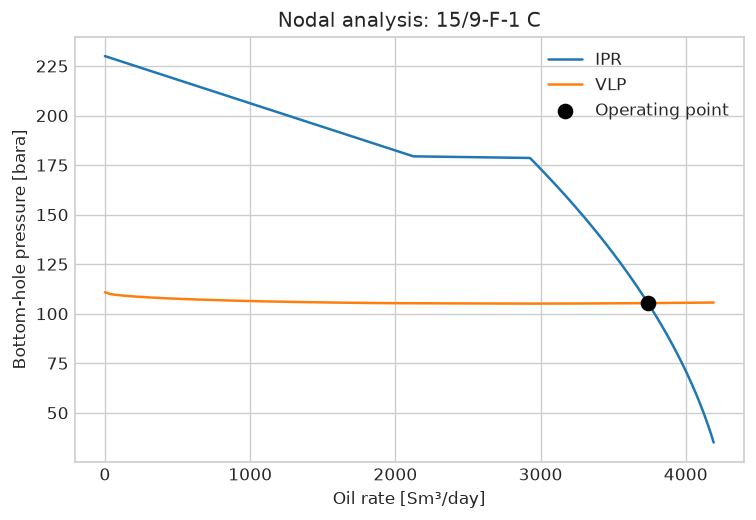

In [8]:
selected_well = productivity.iloc[0]
ipr_curve = np.array(
    [
        ipr_rate(
            selected_well["reservoir_pressure_bara"],
            selected_well["productivity_index_Sm3_day_bar"],
            flowing_pressure,
        )
        for flowing_pressure in pressure_grid
    ]
)
vlp_curve = np.array(
    [vlp_pressure(rate, 0.42, 165.0) for rate in ipr_curve]
)
nodal_figure, nodal_axis = plt.subplots(figsize=(7.2, 4.6))
nodal_axis.plot(ipr_curve, pressure_grid, label="IPR")
nodal_axis.plot(ipr_curve, vlp_curve, label="VLP")
operating_row = nodal_table.iloc[0]
nodal_axis.scatter(
    operating_row["operating_rate_Sm3_day"],
    operating_row["flowing_pressure_bara"],
    s=70,
    color="black",
    label="Operating point",
    zorder=5,
)
nodal_axis.set(
    xlabel="Oil rate [Sm³/day]",
    ylabel="Bottom-hole pressure [bara]",
    title=f"Nodal analysis: {selected_well['well']}",
)
nodal_axis.legend()
plt.show()


## 4. NeqSim wellstream properties and hydraulic basis

The rate model needs density, viscosity, phase fraction, heat
capacity, thermal conductivity, surface tension, and hydrate
tendency over changing pressure, temperature, water cut, and GOR.
The compositional NeqSim fluid is therefore flashed at representative
wellhead and manifold conditions before the hydraulic screen.


In [9]:
wellstream = jneqsim.thermo.system.SystemSrkCPAstatoil(338.15, 70.0)
for component_name, amount in [
    ("nitrogen", 0.004),
    ("CO2", 0.006),
    ("methane", 0.44),
    ("ethane", 0.07),
    ("propane", 0.08),
    ("i-butane", 0.02),
    ("n-butane", 0.04),
    ("n-pentane", 0.03),
    ("water", 0.16),
]:
    wellstream.addComponent(component_name, amount)
wellstream.addTBPfraction("C7", 0.15, 0.16, 0.82)
wellstream.setMixingRule(10)
wellstream.setMultiPhaseCheck(True)
TPflash(wellstream)
wellstream.initPhysicalProperties()
phase_table = pd.DataFrame(
    [
        {
            "phase": str(wellstream.getPhase(index).getPhaseTypeName()),
            "beta": wellstream.getPhase(index).getBeta(),
            "density_kg_m3": wellstream.getPhase(index).getDensity("kg/m3"),
            "viscosity_cP": wellstream.getPhase(index).getViscosity("cP"),
        }
        for index in range(wellstream.getNumberOfPhases())
    ]
)
display(phase_table)


,phase,beta,density_kg_m3,viscosity_cP
0,gas,0.465533,60.897088,0.014099
1,oil,0.377199,658.389793,0.245850
2,aqueous,0.157268,983.608896,0.431829


## 5. Flowline and riser hydraulic screen

The Darcy-Weisbach friction term is

$$\Delta p_f=f\frac{L}{D}\frac{\rho v^2}{2}$$

and static head is $\Delta p_g=\rho g\Delta z$. The mixture model
below is intentionally transparent and is checked against physical
trends. A detailed Volve run should use NeqSim's multiphase pipe
model or a verified specialist model with terrain, holdup, regimes,
mass transfer, and transient initialization.


In [10]:
network_cases = []
for diameter_inch in [6.0, 8.0, 10.0, 12.0]:
    diameter_m = diameter_inch * 0.0254
    area_m2 = math.pi * diameter_m**2 / 4.0
    mass_rate_kg_s = 65.0
    mixture_density_kg_m3 = 185.0
    velocity_m_s = mass_rate_kg_s / (
        mixture_density_kg_m3 * area_m2
    )
    reynolds_number = (
        mixture_density_kg_m3
        * velocity_m_s
        * diameter_m
        / 0.0018
    )
    friction_factor = 0.3164 / reynolds_number**0.25
    friction_bar = (
        friction_factor
        * 6500.0
        / diameter_m
        * mixture_density_kg_m3
        * velocity_m_s**2
        / 2.0
        / 1.0e5
    )
    elevation_bar = (
        mixture_density_kg_m3 * 9.81 * 80.0 / 1.0e5
    )
    network_cases.append(
        {
            "diameter_inch": diameter_inch,
            "velocity_m_s": velocity_m_s,
            "Re": reynolds_number,
            "friction_bar": friction_bar,
            "elevation_bar": elevation_bar,
            "total_pressure_drop_bar": friction_bar + elevation_bar,
        }
    )
network_table = pd.DataFrame(network_cases)
display(network_table)


,diameter_inch,velocity_m_s,Re,friction_bar,elevation_bar,total_pressure_drop_bar
0,6.0,19.261132,301693.534587,197.596261,1.45188,199.048141
1,8.0,10.834387,226270.150940,50.387142,1.45188,51.839022
2,10.0,6.934008,181016.120752,17.458107,1.45188,18.909987
3,12.0,4.815283,150846.767293,7.343215,1.45188,8.795095


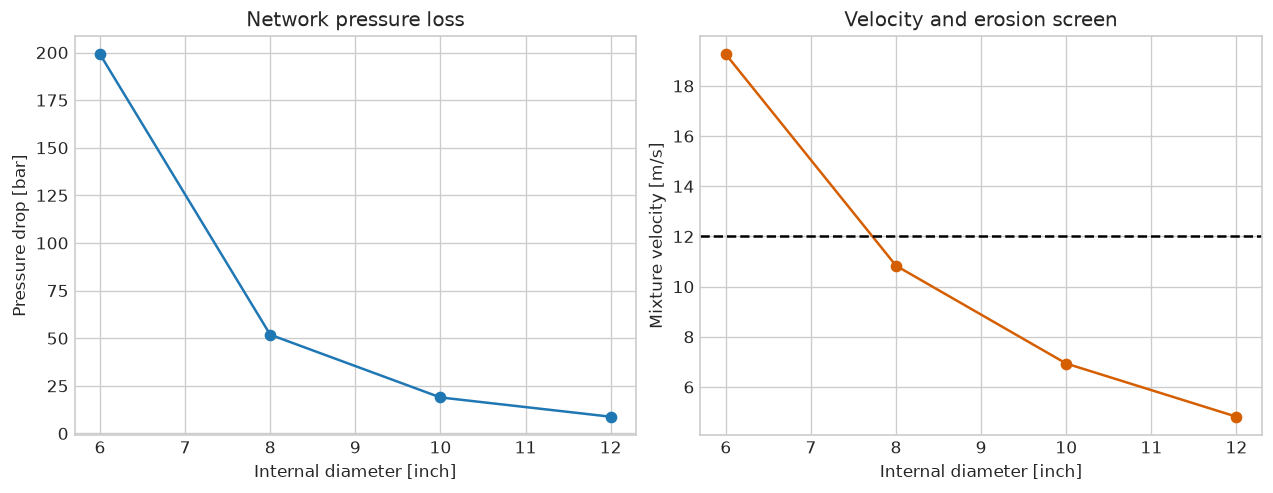

In [11]:
hydraulic_figure, hydraulic_axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.0),
    constrained_layout=True,
)
hydraulic_axes[0].plot(
    network_table["diameter_inch"],
    network_table["total_pressure_drop_bar"],
    marker="o",
)
hydraulic_axes[0].set(
    xlabel="Internal diameter [inch]",
    ylabel="Pressure drop [bar]",
    title="Network pressure loss",
)
hydraulic_axes[1].plot(
    network_table["diameter_inch"],
    network_table["velocity_m_s"],
    marker="o",
    color="#D55E00",
)
hydraulic_axes[1].axhline(12.0, color="black", linestyle="--")
hydraulic_axes[1].set(
    xlabel="Internal diameter [inch]",
    ylabel="Mixture velocity [m/s]",
    title="Velocity and erosion screen",
)
plt.show()


## 6. Thermal profile, hydrate margin, and cooldown

Steady heat loss establishes arrival temperature; shutdown removes
advection and turns the problem into transient cooling of fluid,
pipe wall, insulation, and surroundings. Hydrate risk depends on
local pressure, free water, fluid composition, inhibitors,
subcooling, residence time, and restart path. The screen uses a
lumped time constant and a conservative teaching hydrate boundary.


In [12]:
length_m = np.linspace(0.0, 6500.0, 120)
inlet_temperature_c = 65.0
seawater_temperature_c = 6.0
overall_heat_transfer_w_m2_k = 2.2
pipe_diameter_m = 0.254
mass_rate_kg_s = 65.0
heat_capacity_j_kg_k = 2600.0
decay = (
    overall_heat_transfer_w_m2_k
    * math.pi
    * pipe_diameter_m
    * length_m
    / (mass_rate_kg_s * heat_capacity_j_kg_k)
)
flowing_temperature_c = seawater_temperature_c + (
    inlet_temperature_c - seawater_temperature_c
) * np.exp(-decay)
pressure_bara = 62.0 - 12.0 * length_m / length_m.max()
hydrate_temperature_c = 15.0 + 0.055 * pressure_bara
hydrate_margin_c = flowing_temperature_c - hydrate_temperature_c

cooldown_hours = np.linspace(0.0, 72.0, 145)
thermal_time_constant_h = 19.0
cooldown_temperature_c = seawater_temperature_c + (
    flowing_temperature_c[-1] - seawater_temperature_c
) * np.exp(-cooldown_hours / thermal_time_constant_h)
hydrate_crossing = np.flatnonzero(
    cooldown_temperature_c <= hydrate_temperature_c[-1]
)
time_to_hydrate_h = (
    float(cooldown_hours[hydrate_crossing[0]])
    if len(hydrate_crossing)
    else float("inf")
)
print(
    {
        "arrival temperature C": round(flowing_temperature_c[-1], 2),
        "minimum flowing hydrate margin C": round(hydrate_margin_c.min(), 2),
        "time to hydrate boundary h": time_to_hydrate_h,
    }
)


{'arrival temperature C': np.float64(61.15), 'minimum flowing hydrate margin C': np.float64(43.4), 'time to hydrate boundary h': 29.5}


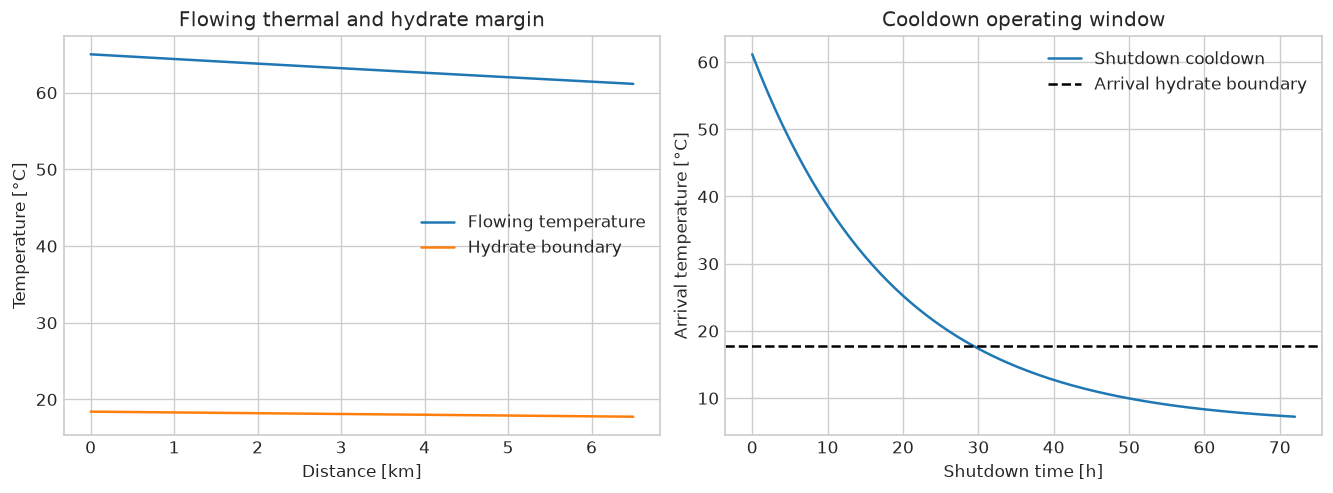

In [13]:
thermal_figure, thermal_axes = plt.subplots(
    1,
    2,
    figsize=(11.0, 4.0),
    constrained_layout=True,
)
thermal_axes[0].plot(
    length_m / 1000.0,
    flowing_temperature_c,
    label="Flowing temperature",
)
thermal_axes[0].plot(
    length_m / 1000.0,
    hydrate_temperature_c,
    label="Hydrate boundary",
)
thermal_axes[0].set(
    xlabel="Distance [km]",
    ylabel="Temperature [°C]",
    title="Flowing thermal and hydrate margin",
)
thermal_axes[0].legend()
thermal_axes[1].plot(
    cooldown_hours,
    cooldown_temperature_c,
    label="Shutdown cooldown",
)
thermal_axes[1].axhline(
    hydrate_temperature_c[-1],
    color="black",
    linestyle="--",
    label="Arrival hydrate boundary",
)
thermal_axes[1].set(
    xlabel="Shutdown time [h]",
    ylabel="Arrival temperature [°C]",
    title="Cooldown operating window",
)
thermal_axes[1].legend()
plt.show()


## 7. Network operating envelope and handoff

The facility inlet is the intersection of reservoir deliverability,
well VLP, choke policy, network pressure drop, arrival temperature,
and flow-assurance limits. The handoff therefore contains an
envelope, not only one design point.


In [14]:
envelope = pd.DataFrame(
    {
        "case": ["turndown", "normal", "peak"],
        "well_count": [2, 4, 5],
        "oil_rate_Sm3_day": [900.0, 2600.0, 4100.0],
        "gas_rate_Sm3_day": [0.16e6, 0.48e6, 0.82e6],
        "water_rate_Sm3_day": [500.0, 2900.0, 6200.0],
        "arrival_pressure_bara": [47.0, 52.0, 55.0],
        "arrival_temperature_C": [20.0, 27.0, 34.0],
    }
)
envelope["liquid_rate_Sm3_day"] = (
    envelope["oil_rate_Sm3_day"]
    + envelope["water_rate_Sm3_day"]
)
display(envelope)

wells_contract_path = vc.write_contract(
    work_dir / "03_wells_surf_envelope.json",
    {
        "discipline": "wells-surf-flow-assurance",
        "data_status": (
            "MEASURED_VOLVE"
            if source.measured_data_loaded
            else "DEMONSTRATION_FALLBACK"
        ),
        "nodal_records": nodal_table.to_dict("records"),
        "network_records": network_table.to_dict("records"),
        "facility_inlet_envelope": envelope.to_dict("records"),
        "time_to_hydrate_boundary_h": time_to_hydrate_h,
        "limitations": [
            "screening VLP and homogeneous network hydraulics",
            "lumped cooldown model",
            "specialist transient model required for restart and slugging",
        ],
    },
    source,
)
print(wells_contract_path)


/workspace/scratch/95ecac0092cf/neqsim-colab-volve/notebooks/fielddevelopment/volve/work/03_wells_surf_envelope.json


,case,well_count,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,arrival_pressure_bara,arrival_temperature_C,liquid_rate_Sm3_day
0,turndown,2,900.0,160000.0,500.0,47.0,20.0,1400.0
1,normal,4,2600.0,480000.0,2900.0,52.0,27.0,5500.0
2,peak,5,4100.0,820000.0,6200.0,55.0,34.0,10300.0


In [15]:
checks = {
    "five trajectories present": trajectories["well"].nunique() == 5,
    "TVD increases downhole": bool(
        trajectories.groupby("well")["tvd_m"]
        .apply(lambda values: np.diff(values).min() >= 0.0)
        .all()
    ),
    "nodal rates positive": bool(
        nodal_table["operating_rate_Sm3_day"].gt(0.0).all()
    ),
    "nodal mismatch bounded": bool(
        nodal_table["pressure_mismatch_bar"].lt(2.0).all()
    ),
    "larger pipe reduces pressure loss": bool(
        network_table["total_pressure_drop_bar"].is_monotonic_decreasing
    ),
    "thermal arrays finite": np.isfinite(flowing_temperature_c).all(),
    "hydrate crossing positive": time_to_hydrate_h > 0.0,
    "envelope ordered": bool(
        envelope["oil_rate_Sm3_day"].is_monotonic_increasing
    ),
    "handoff exists": wells_contract_path.is_file(),
}
validation = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(validation)
if not validation["passed"].all():
    raise AssertionError(validation.loc[~validation["passed"], "check"].tolist())
print(f"All {len(checks)} wells and SURF checks passed.")


All 9 wells and SURF checks passed.


,check,passed
0,five trajectories present,True
1,TVD increases downhole,True
2,nodal rates positive,True
3,nodal mismatch bounded,True
4,larger pipe reduces pressure loss,True
5,thermal arrays finite,True
6,hydrate crossing positive,True
7,envelope ordered,True
8,handoff exists,True


## Interpretation and next notebook

Subsurface potential is reduced by VLP, choke, network, thermal, and
integrity constraints before reaching the platform. Notebook 4 uses
the low/normal/peak inlet envelope to size and simulate separation,
oil stabilization, gas compression, cooling and dehydration duty,
produced-water treatment, utilities, emissions, turndown, and
bottlenecks with NeqSim.
